Running K = 0.1
Running K = 0.2
Running K = 0.3
Running K = 0.4
Running K = 0.5


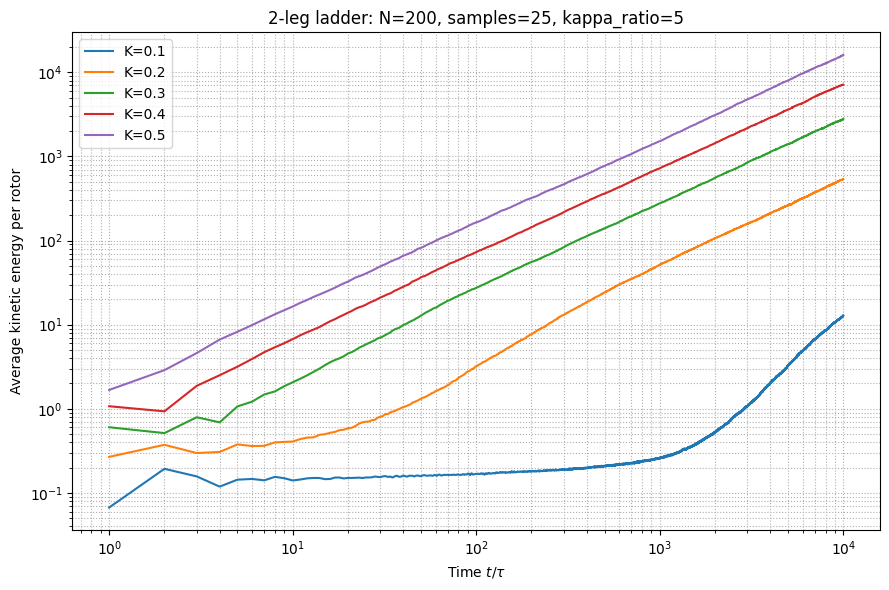

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parameters
# -----------------------
N = 200
tau = 1.0
timesteps = 10000
record_steps = 1
n_record = timesteps // record_steps
K_list = [0.1, 0.2, 0.3, 0.4, 0.5]
samples = 25
kappa_ratio = 5

# -----------------------
# Simulation function
# -----------------------
def simulate_ladder(K, N, tau, timesteps, kappa_ratio, record_steps=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    kappa_parallel = K / tau
    kappa_perp = kappa_ratio * kappa_parallel


    phi = rng.uniform(0, 2*np.pi, (N, 2))
    p = np.zeros((N, 2))

    E_rec = np.zeros(n_record)
    rec_idx = 0

    for step in range(timesteps):

        phi_left = np.roll(phi, 1, axis=0)
        phi_right = np.roll(phi, -1, axis=0)


        p += kappa_parallel * (np.sin(phi_left - phi) - np.sin(phi - phi_right))


        delta_rung = phi[:, 0] - phi[:, 1]

        s_rung = np.sin(delta_rung)
        p[:, 0] += -kappa_perp * s_rung
        p[:, 1] += +kappa_perp * s_rung

        # free evolution
        phi = (phi + p * tau) % (2 * np.pi)

        # record
        if (step + 1) % record_steps == 0:
            E_rec[rec_idx] = np.mean(0.5 * p**2)
            rec_idx += 1

    return E_rec

# -----------------------
# Run sweep, average and plot
# -----------------------
time_array = (np.arange(1, n_record+1) * record_steps)  # in units of t/tau (tau=1)
plt.figure(figsize=(9,6))

for K in K_list:
    print("Running K =", K)
    E_accum = np.zeros(n_record)
    rng = np.random.default_rng(12345)
    for s in range(samples):
        E_accum += simulate_ladder(K, N, tau, timesteps, kappa_ratio, record_steps, rng=rng)

        rng = np.random.default_rng(int(rng.integers(1e9) ^ s))
    E_avg = E_accum / samples
    plt.plot(time_array, E_avg, label=f"K={K}")

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Time $t/\tau$")
plt.ylabel("Average kinetic energy per rotor")
plt.title(f"2-leg ladder: N={N}, samples={samples}, kappa_ratio={kappa_ratio}")
plt.legend()
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()
